Notebook to place a pattern on a FIB image

In [58]:
# general
from __future__ import annotations
import os
import logging
from copy import deepcopy
import tempfile
import typing

# for display
import napari
import PIL
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import tifffile

# for the fibsem structures
from fibsem.structures import FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages, TrenchPattern
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire

# Adaptive polishing
from adaptive_polish import gis_measurement as gm

if typing.TYPE_CHECKING:
    from numpy.typing import NDArray, DTypeLike

In [59]:
base_path = Path.home() / "OneDrive - The Rosalind Franklin Institute"/ "Documents" / "test data" / "adaptive milling" / "2024segmentation_testdata"
model_path = base_path / "2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp"
bitmaps_path = base_path.parent / "tmp" / "plots" / "modified_GIS_m"
config_path = (
    Path.cwd().parent.parent.parent.parent
    / "fibsem"
    / "fibsem"
    / "config"
    / "microscope-configuration-demo2.yaml"
)
protocol_path = Path.cwd() / "spoof_microscope_protocol.yaml"

WINDOW_SIZE_M = 1e-7
PIXEL_SIZE_M = 1.3020833333333335e-08 * 2 # This is incorrect, get the pixel size from the image metadata instead!

In [60]:
gm.init_model_with_path(model_path=model_path)

2025-01-08 19:24:07,624 — root — INFO — __init__:174 — model path:C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\test data\adaptive milling\2024segmentation_testdata\2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp
2025-01-08 19:24:07,626 — root — INFO — __init__:180 — DL device: cpu


In [61]:
# Set up test microscope
microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2025-01-08 19:24:09,505 — root — INFO — connect_to_microscope:5399 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2025-01-08 19:24:09,507 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2025-01-08-07-24-09PM


In [107]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2025-01-08 19:27:32,542 — root — INFO — acquire_image:6378 — acquiring new ELECTRON image.
2025-01-08 19:27:32,543 — root — INFO — acquire_image:6379 — resolution:[1536, 1024], hfw:4e-05
2025-01-08 19:27:32,545 — root — INFO — acquire_image:6386 — SEM
2025-01-08 19:27:32,546 — root — INFO — load:141 — Loading C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\test data\adaptive milling\2024segmentation_testdata\SEM\02C_SEM_stop.tif as spoof image
2025-01-08 19:27:32,866 — root — INFO — acquire_image:6413 — img_data.type:<class 'numpy.ndarray'>
2025-01-08 19:27:32,868 — root — INFO — acquire_image:6414 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2025-01-08 19:27:32,870 — root — INFO — acquire_image:6418 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2025-01-08 19:27:33,168 — root — INFO — acquire_image:6422 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2025-01-08 19:27:33,169 — root — INFO — acquire_image:6436

Starting with a TrenchPattern(name='Trench', required_keys=('lamella_width', 'lamella_height', 'trench_height', 'size_ratio', 'offset', 'depth', 'cross_section', 'time', 'path'), point=Point(x=0.0, y=0.0, name=None))


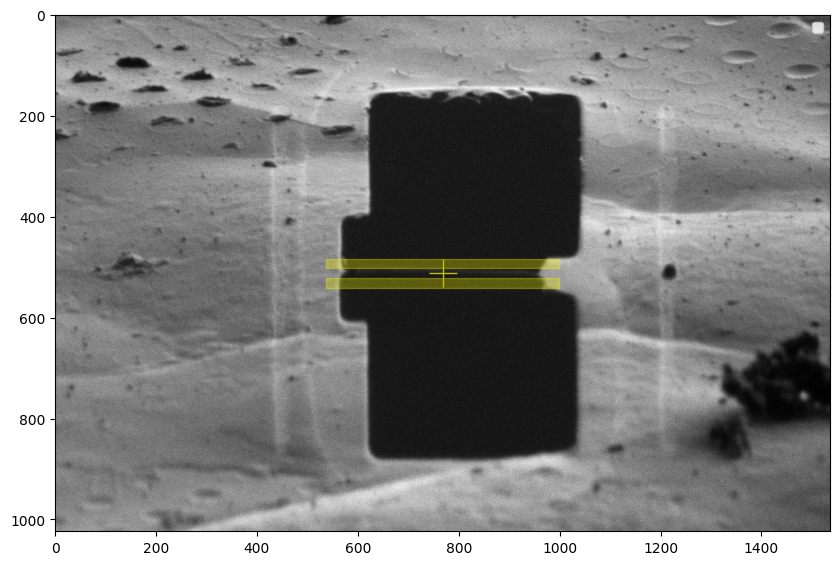

In [108]:
# Place pattern on FIB image from original protocol.yaml file
stages = get_milling_stages("lamella", settings.protocol["milling"])
print(f"Starting with a {stages[0].pattern}")
fig = draw_milling_patterns(ib_image, stages)

In [109]:
def measure_GIS_modified(
    mask_gis_clean: np.array, window_size_m: int, pixel_size_m: float
) -> np.array:
    # Get window size in px
    window_size_px = int(window_size_m / pixel_size_m)
    logging.info(f"window_size_px: {window_size_px}")

    # Calculate average GIS thickness in windows

    # Sum to get thickness along x in pixels
    GIS_pxbypx = np.sum(mask_gis_clean, axis=0).astype(np.float32)

    # Pad with zeros to fulfil window size criteria
    GIS_pxbypx_pad = np.pad(
        GIS_pxbypx,
        (0, window_size_px - len(GIS_pxbypx) % window_size_px),
        constant_values=np.nan,
    )

    # Get left and right limits from where the mean should be calculated from
    GIS_pxbypx_where_above_zero = np.where(GIS_pxbypx_pad > 0)
    xlim_min = GIS_pxbypx_where_above_zero[0][0]  # first occurrence along x
    xlim_max = GIS_pxbypx_where_above_zero[0][-1]  # last occurrence along x

    # make the L and R limits of the lamella x% smaller
    lamella_width_px = xlim_max - xlim_min
    lamella_width_to_cut = int(0.05 * lamella_width_px)  # cut 5% from each end
    xlim_min = lamella_width_to_cut + xlim_min
    xlim_max = xlim_max - lamella_width_to_cut

    GIS_pxbypx_NaNed = np.copy(GIS_pxbypx_pad).astype(np.float32)
    GIS_pxbypx_NaNed[:xlim_min] = np.nan
    GIS_pxbypx_NaNed[xlim_max:] = np.nan

    # This mean will discard nan areas
    # GIS_windowed = np.nanmedian(GIS_pxbypx_NaNed.reshape(-1, window_size_px), axis=1)
    stack = [
        GIS_pxbypx_NaNed[_ : _ + window_size_px]
        for _ in range(GIS_pxbypx_NaNed.size - window_size_px)
    ]
    GIS_windowed = np.nanmedian(
        stack,
        axis=1,
    )
    # Convert to m
    GIS_m = GIS_windowed * pixel_size_m

    # Make any value with 0's, i.e. no GIS measured, NaNs
    GIS_m[np.where(GIS_m == 0)] = np.nan

    return GIS_m, (xlim_min, xlim_max)

2025-01-08 19:27:34,467 — root — INFO — get_prepreds_tfms:59 — imgsize:(1024, 1536), new_size:[512, 768]
2025-01-08 19:27:34,506 — root — INFO — get_prediction:210 — data1.shape:torch.Size([1, 512, 768])
2025-01-08 19:27:37,187 — root — INFO — get_prediction:218 — pred0.shape:torch.Size([1, 4, 512, 768])
2025-01-08 19:27:37,309 — root — INFO — clean_prediction:91 — clean_prediction with prediction.shape:(1024, 1536), pixel_size_m:2.604166666666667e-08
2025-01-08 19:27:37,380 — root — INFO — measure_GIS_modified:6 — window_size_px: 3
2025-01-08 19:27:37,393 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()
Lamella width is 8.619791666666668e-06 m


C:\Users\tpr78264\AppData\Local\Temp\ipykernel_26556\864178448.py:41: RuntimeWarning: All-NaN slice encountered
  GIS_windowed = np.nanmedian(


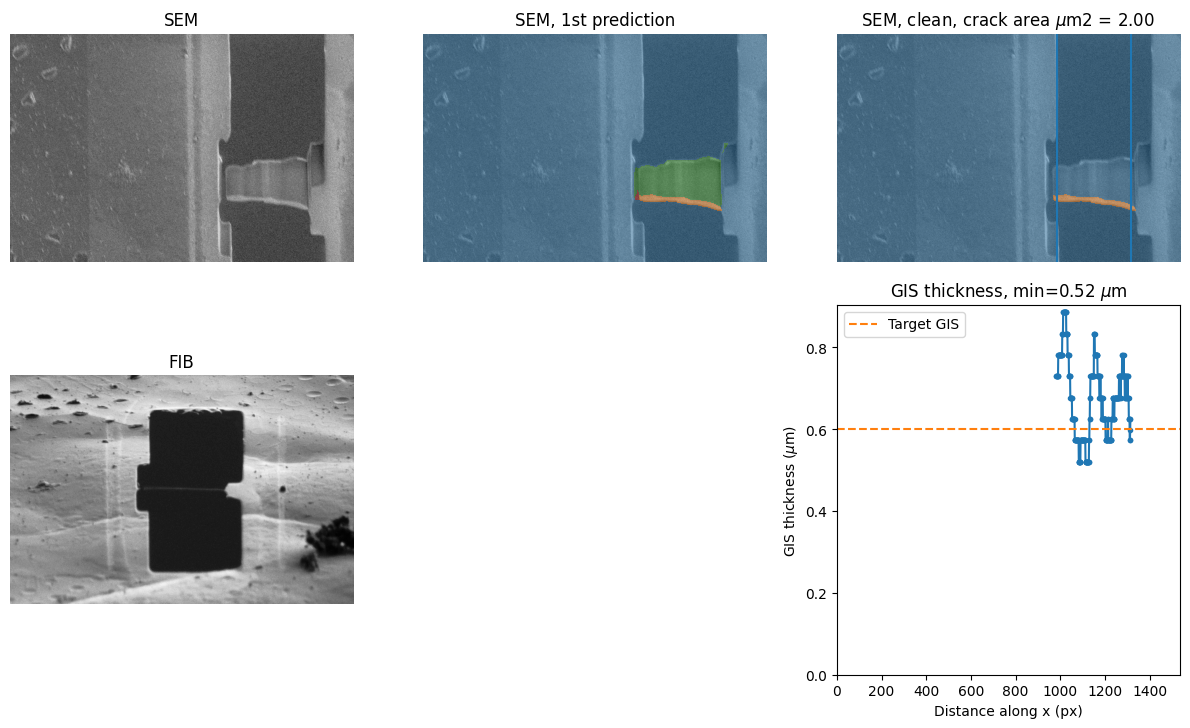

In [110]:
# Find the lamella width based on SEM image segmentation
prediction = gm.segment(eb_image.data)
clean_prediction = gm.clean_prediction(prediction=prediction, pixel_size_m=PIXEL_SIZE_M)
gis_thickness_m, xlims = measure_GIS_modified(mask_gis_clean=clean_prediction, window_size_m=WINDOW_SIZE_M, pixel_size_m=PIXEL_SIZE_M)
gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
    crack_area_m2=float(settings.protocol["adaptive_polish"]["max_crack_area_m2"]),
    xlims=xlims,
    fib_screenshot=None,  # need to figure out how to pass this to plot,
)
lamella_width = (xlims[1] - xlims[0]) * ib_image.metadata.pixel_size.x
print(f"Lamella width is {lamella_width} m")

In [111]:
def create_milling_bitmap_array(
    gis_m: NDArray[np.floating],
    gis_stop_m: float,
    gis_full_power_m: float,
    gis_resolution_m: typing.Union[float, None] = None,
    bitmap_resolution_m: typing.Union[float, None] = None,
    dtype: DTypeLike = np.uint8,
    nan_value: float = 0,
) -> NDArray[typing.Any]:
    """
    Strength multiplier should be between 0 and 1

    If bitmap_resolution_m and gis_resolution_m are None, no pixel interpolation is used.
    """
    dt = np.dtype(dtype)

    assert np.issubdtype(dt, np.integer), "Only integer dtypes accepted"

    n = len(gis_m)
    if gis_resolution_m is None and bitmap_resolution_m is None:
        factor = 1
    elif gis_full_power_m is not None and bitmap_resolution_m is not None:
        factor = bitmap_resolution_m / gis_resolution_m
    else:
        raise TypeError(
            "gis_resolution_m and bitmap_resolution_m must both be None or floats, the types cannot be mixed"
        )

    x = np.linspace(0, n - 1, (n - 1) * factor + 1)
    gis_m = gis_m.copy()
    gis_m[np.isnan(gis_m)] = nan_value
    interpolated = np.interp(x, range(n), gis_m)

    # Rescale to uint8 (clips to 0 at gis_stop_m and 255 at gis_full_power_m)
    rescaled = (
        np.round(
            np.interp(
                interpolated,
                (gis_stop_m, gis_full_power_m),
                (np.iinfo(dt).min, np.iinfo(dt).max),
            )
        )
        .astype(dt)
        .reshape(1, -1)
    )

    return rescaled

In [112]:
# The bitmap needs to be offset by the window size / 2 (in pixels) as the medium rank filter isn't centred around the pixel
bitmap_offset = int(np.floor(WINDOW_SIZE_M / (2 * PIXEL_SIZE_M)))
bitmap_array = create_milling_bitmap_array(
    gis_m=gis_thickness_m[xlims[0] - bitmap_offset : xlims[1] - bitmap_offset],
    gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
    gis_full_power_m=float(settings.protocol["adaptive_polish"]["gis_full_power_m"]),
)
print(f"bitmap min, max: {bitmap_array.min()}, {bitmap_array.max()}")
bitmap = PIL.Image.fromarray(bitmap_array)

bitmap min, max: 0, 182


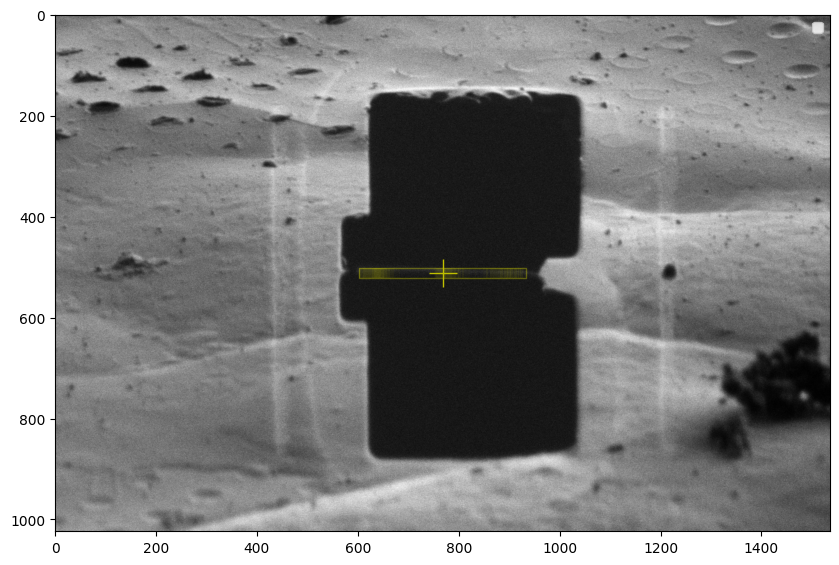

In [113]:
# Plot BitmapPattern via directly
from fibsem.patterning import BitmapPattern
try:
    with tempfile.NamedTemporaryFile(suffix=".bmp", mode="w+b", delete=False) as tmp_f:
        bitmap.save(tmp_f, format="BMP")
    bitmap_config = {
        "width": lamella_width,
        "height": settings.protocol["milling"]["lamella"]["stages"][0][
            "lamella_height"
        ],
        "depth": settings.protocol["milling"]["lamella"]["stages"][0]["depth"],
        "centre_x": 0,
        "centre_y": 0,
        "pattern": "BitmapPattern",
        "rotation": 0,
        "cleaning_cross_section": False,
        "scan_direction": "ToptoBottom",
        "path": tmp_f.name,
    }
    bitmap_pattern_obj = BitmapPattern()
    bitmap_pattern_obj.define(protocol=bitmap_config)
    stages[0].pattern = bitmap_pattern_obj

    fig = draw_milling_patterns(ib_image, stages)
finally:
    os.unlink(tmp_f.name)

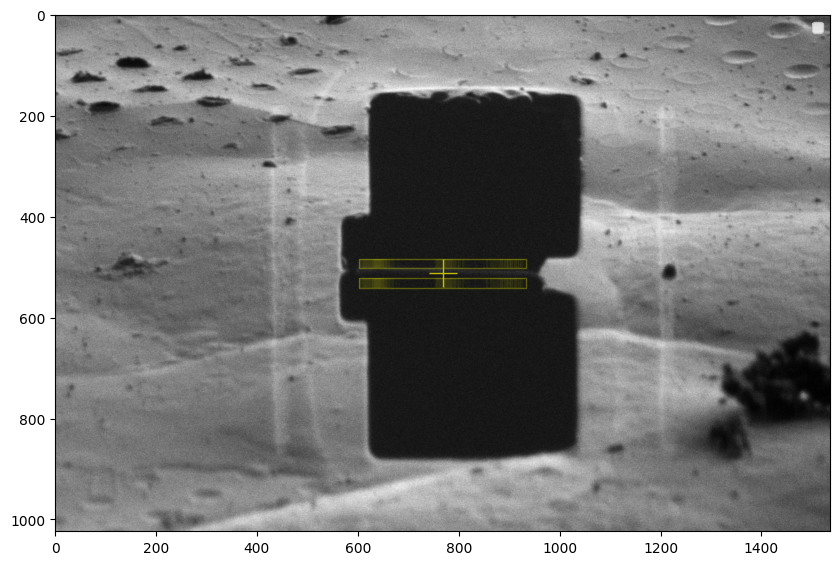

In [114]:
# Plot TrenchBitmapPattern via directly
from fibsem.patterning import TrenchBitmapPattern

try:
    with tempfile.NamedTemporaryFile(suffix=".bmp", mode="w+b", delete=False) as tmp_f:
        bitmap.save(tmp_f, format="BMP")
    bitmap_config = {
        "lamella_width": lamella_width,
        "lamella_height": settings.protocol["milling"]["lamella"]["stages"][0][
            "lamella_height"
        ],
        "trench_height": settings.protocol["milling"]["lamella"]["stages"][0][
            "trench_height"
        ],
        "depth": settings.protocol["milling"]["lamella"]["stages"][0]["depth"],
        "centre_x": 0,
        "centre_y": 0,
        "pattern": "BitmapPattern",
        "rotation": 0,
        "cleaning_cross_section": False,
        "scan_direction": "ToptoBottom",
        "path": tmp_f.name,
    }
    bitmap_pattern_obj = TrenchBitmapPattern()
    bitmap_pattern_obj.define(protocol=bitmap_config)
    stages[0].pattern = bitmap_pattern_obj

    fig = draw_milling_patterns(ib_image, stages)
finally:
    os.unlink(tmp_f.name)


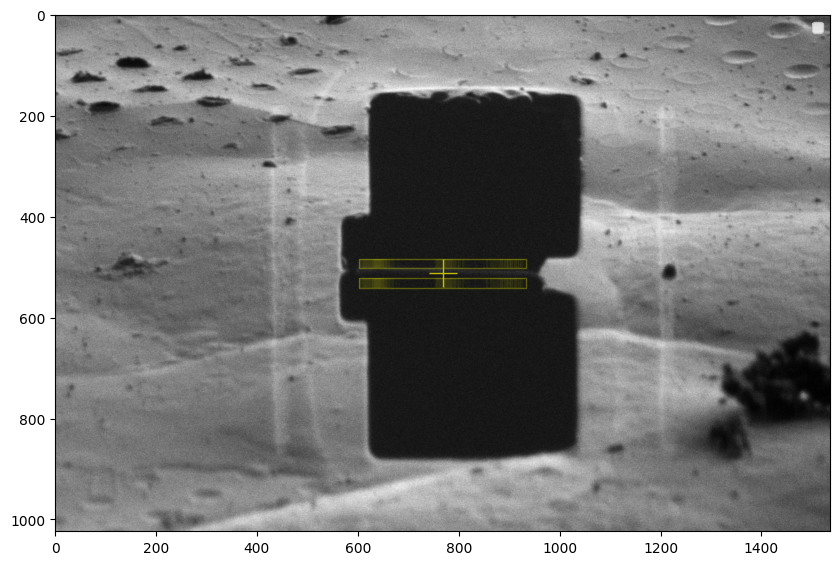

In [115]:
# Use TrenchBitmapPattern via protocol
try:
    with tempfile.NamedTemporaryFile(suffix=".bmp", mode="w+b", delete=False) as tmp_f:
        bitmap.save(tmp_f, format="BMP")

    try:
        previous_protocol = settings.protocol["milling"]["lamella"]["stages"][0]

        # Place pattern on image from edited pattern
        ap_milling_protocol = deepcopy(previous_protocol)
        ap_milling_protocol["lamella_width"] = lamella_width
        # ap_milling_protocol["hfw"] = 4e-05
        # ap_milling_protocol["trench_height"] = 5e-7
        ap_milling_protocol["type"] = "TrenchBitmapPattern"
        ap_milling_protocol["path"] = tmp_f.name
        ap_milling_protocol["name"] = "Adjusted adaptive polishing"
        if (
            settings.protocol["milling"]["lamella"]["stages"][-1]["name"]
            == "Adaptive polishing"
        ):
            settings.protocol["milling"]["lamella"]["stages"][0] = ap_milling_protocol
        elif (
            settings.protocol["milling"]["lamella"]["stages"][-1]["name"]
            == "Adjusted adaptive polishing"
        ):
            settings.protocol["milling"]["lamella"]["stages"][-1] = ap_milling_protocol
        settings.protocol["milling"]["lamella"]["stages"][-1]["patterning_mode"] = (
            "Serial"
        )
        # settings.protocol["milling"]["lamella"]["stages"][0] = ap_milling_protocol
        stages = get_milling_stages("lamella", settings.protocol["milling"])
        fig = draw_milling_patterns(ib_image, stages)

    # Reset back to original state
    finally:
        settings.protocol["milling"]["lamella"]["stages"][0] = previous_protocol
finally:
    os.unlink(tmp_f.name)